#### Summary / Question of Interest

##### **Context**
This dataset is originally from the National Institute of Diabetes and Digestive and Kidney Diseases. 

The **objective** of the dataset is to **diagnostically predict whether or not a patient has diabetes**, based on certain diagnostic measurements included in the dataset. Several constraints were placed on the selection of these instances from a larger database. In particular, **all patients here are females at least 21 years old** of Pima Indian heritage.

##### **Content**
The datasets consists of several medical predictor variables and one target variable, Outcome. Predictor variables includes the number of pregnancies the patient has had, their BMI, insulin level, age, and so on.

#### Imports

In [174]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from plotnine import *
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score, accuracy_score
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV
from xgboost import XGBClassifier
import xgboost as xgb
import warnings

warnings.filterwarnings('ignore')

seed = 1980

##### Get Pima Data

In [101]:
# Download latest version
path = kagglehub.dataset_download("uciml/pima-indians-diabetes-database")

pima_df = pd.read_csv(f'{path}/diabetes.csv')

# simplify col names
pima_df.columns = pima_df.columns.str.replace(" ", "_").str.lower()

In [102]:
pima_df.head(10)

,pregnancies,glucose,bloodpressure,skinthickness,insulin,bmi,diabetespedigreefunction,age,outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [103]:
pd.concat([pima_df.describe(), pima_df.median().rename('median').to_frame().T])

,pregnancies,glucose,bloodpressure,skinthickness,insulin,bmi,diabetespedigreefunction,age,outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000
median,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000


**High Level Notes on Data:**
- Nothing is categorical, it's all numeric data
- All Females and older than 20 years old 
- Glucose, BP, Age *could* all be clustered
    - Age would be a simple cluster on ~10 years
    - Glucode and BP *could* be based on what's considered an intervention level

Based on initial review, LinearRegression and a simple tree model are easy to set up and interpretable

#### Data Cleansing

Do some simple cleaning (missingness) first

In [104]:
pima_df.isnull().sum()

pregnancies                 0
glucose                     0
bloodpressure               0
skinthickness               0
insulin                     0
bmi                         0
diabetespedigreefunction    0
age                         0
outcome                     0
dtype: int64

In [105]:
(pima_df == 0).sum()

pregnancies                 111
glucose                       5
bloodpressure                35
skinthickness               227
insulin                     374
bmi                          11
diabetespedigreefunction      0
age                           0
outcome                     500
dtype: int64

**Notes**: 
No nulls is very good, lots of 0s, need to look at why for each variable and if it makes sense (it doens't for glucose, bp, skin-thickness and bmi or age)

#### EDA

Distributions of Data

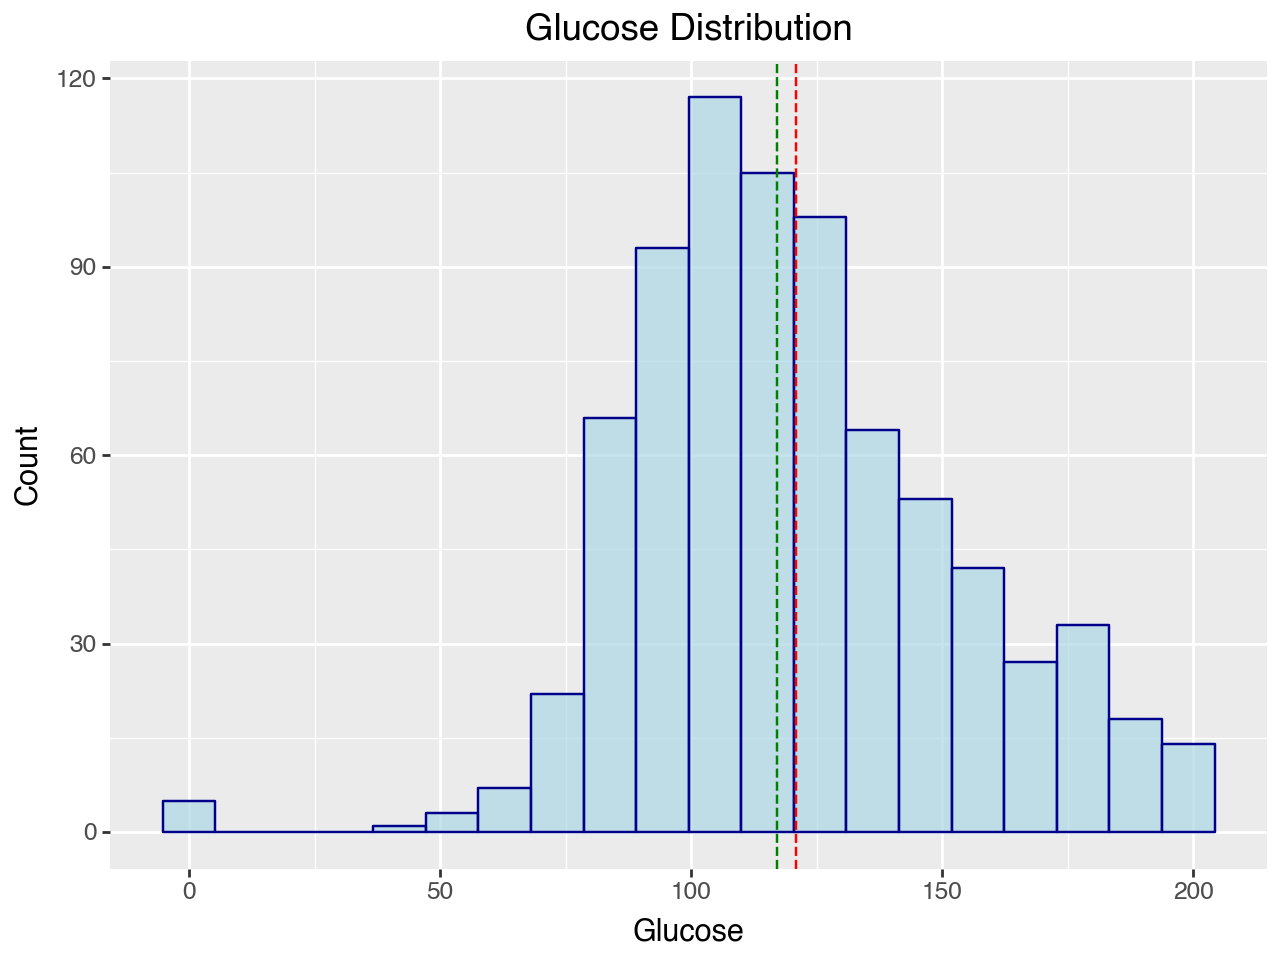

In [106]:
mean = pima_df['glucose'].mean()
median = pima_df['glucose'].median()

(ggplot(pima_df, aes(x='glucose')) + 
        geom_histogram(bins = 20, 
                       fill = 'lightblue', 
                       color = 'darkblue',
                       alpha = 0.7) +
        labs(title = 'Glucose Distribution', x = 'Glucose', y = 'Count') + 
        geom_vline(xintercept=mean, color='red', linetype='dashed') +
        geom_vline(xintercept=median, color='green', linetype='dashed'))


**Notes:**
Almost standard distribution, glucose below 40 oor 50 maybe isn't biologically possible?

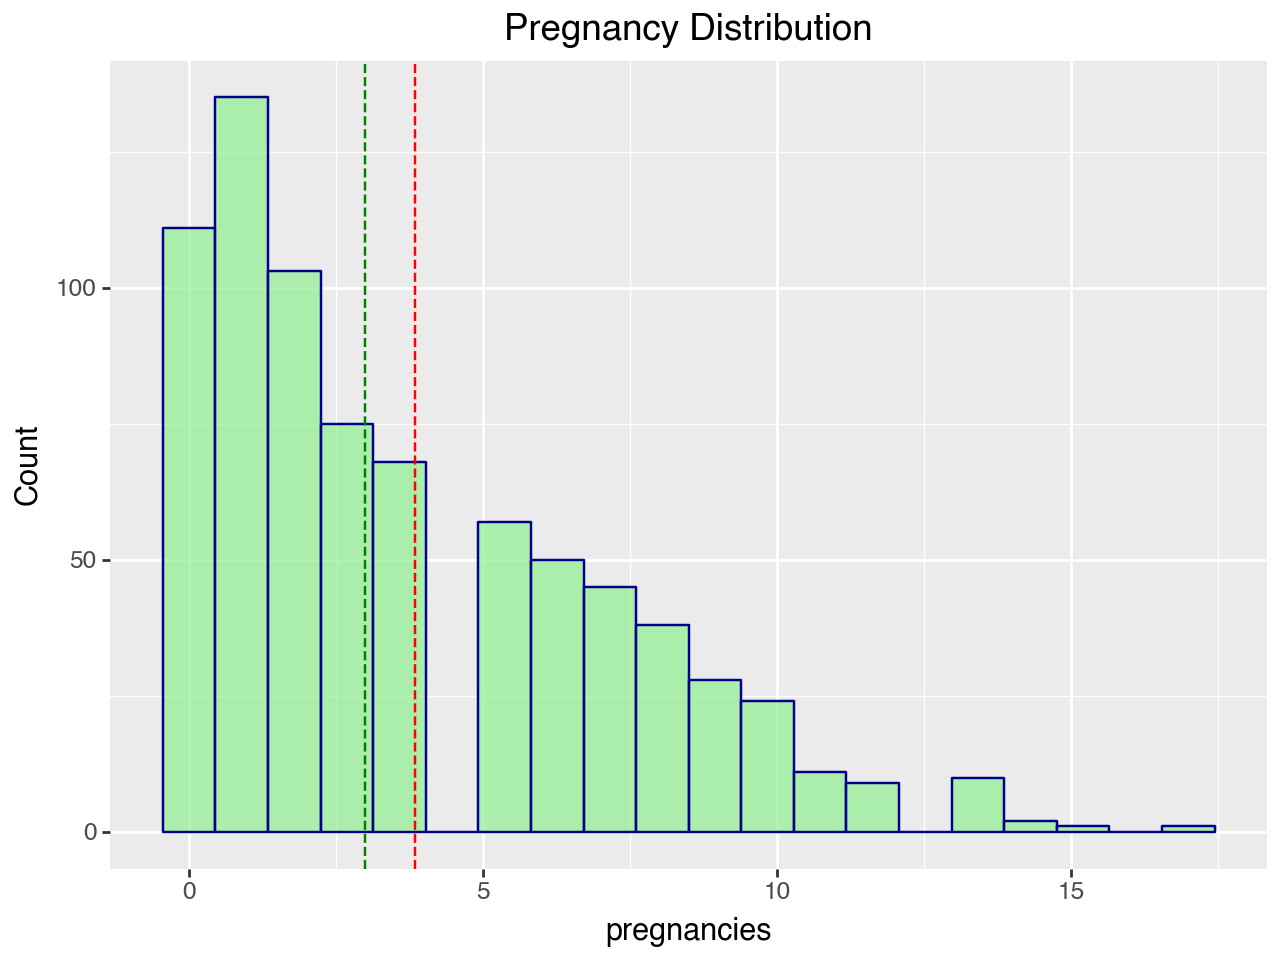

In [107]:
mean = pima_df['pregnancies'].mean()
median = pima_df['pregnancies'].median()

(ggplot(pima_df, aes(x='pregnancies')) + 
        geom_histogram(bins = 20, 
                       fill = 'lightgreen', 
                       color = 'darkblue',
                       alpha = 0.7) +
        labs(title = 'Pregnancy Distribution', x = 'pregnancies', y = 'Count') + 
        geom_vline(xintercept=mean, color='red', linetype='dashed') +
        geom_vline(xintercept=median, color='green', linetype='dashed'))


**Notes:**
Skews to the right (median > mean).  10+ pregnancies is an outlier? 

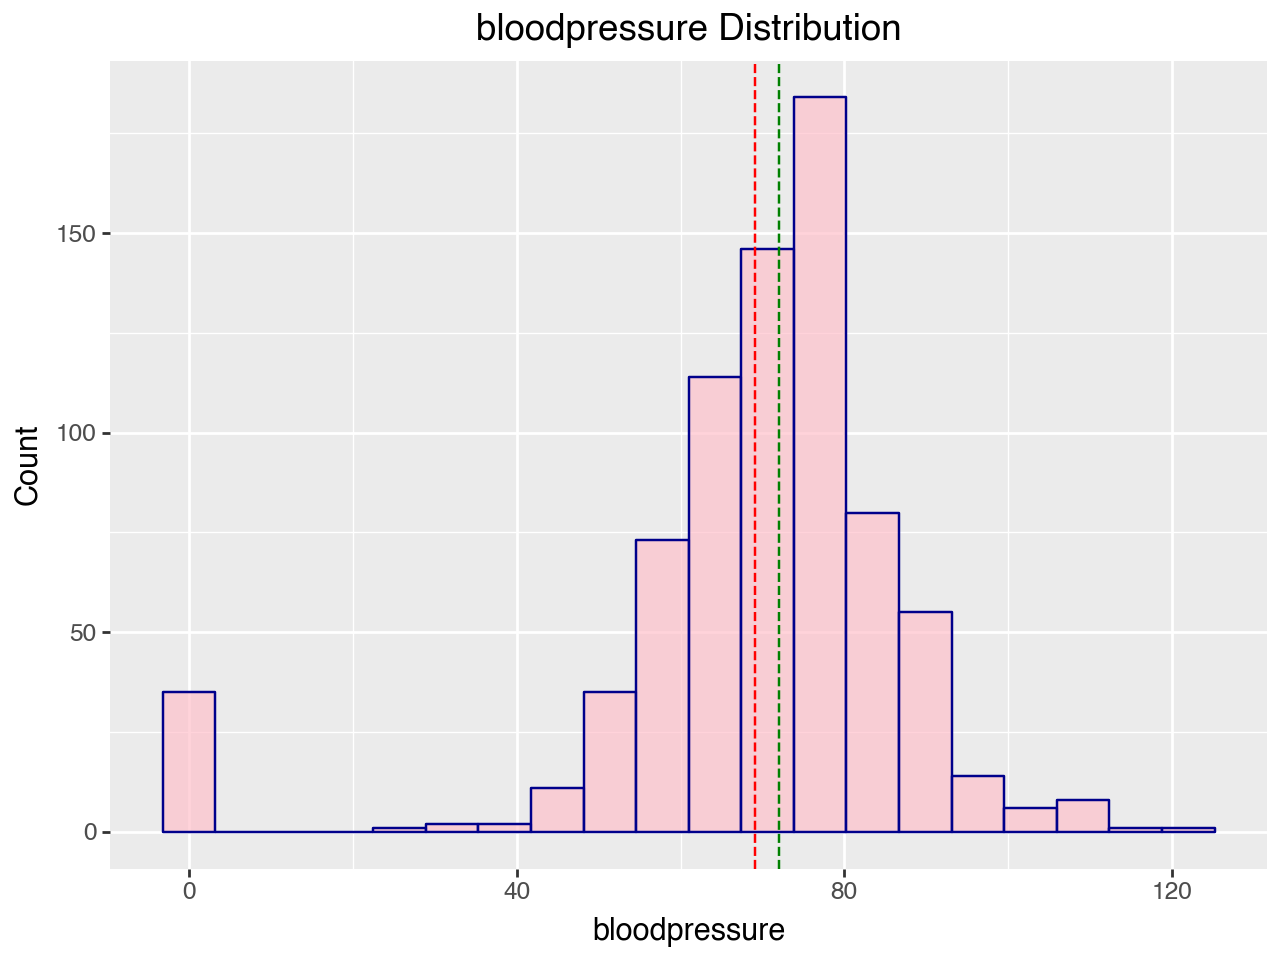

In [108]:
mean = pima_df['bloodpressure'].mean()
median = pima_df['bloodpressure'].median()

(ggplot(pima_df, aes(x='bloodpressure')) + 
        geom_histogram(bins = 20, 
                       fill = 'pink', 
                       color = 'darkblue',
                       alpha = 0.7) +
        labs(title = 'bloodpressure Distribution', x = 'bloodpressure', y = 'Count') + 
        geom_vline(xintercept=mean, color='red', linetype='dashed') +
        geom_vline(xintercept=median, color='green', linetype='dashed'))


**Notes:**
Not a normal distribution.  Can't get rid of the zereos, but we'll impute with the median

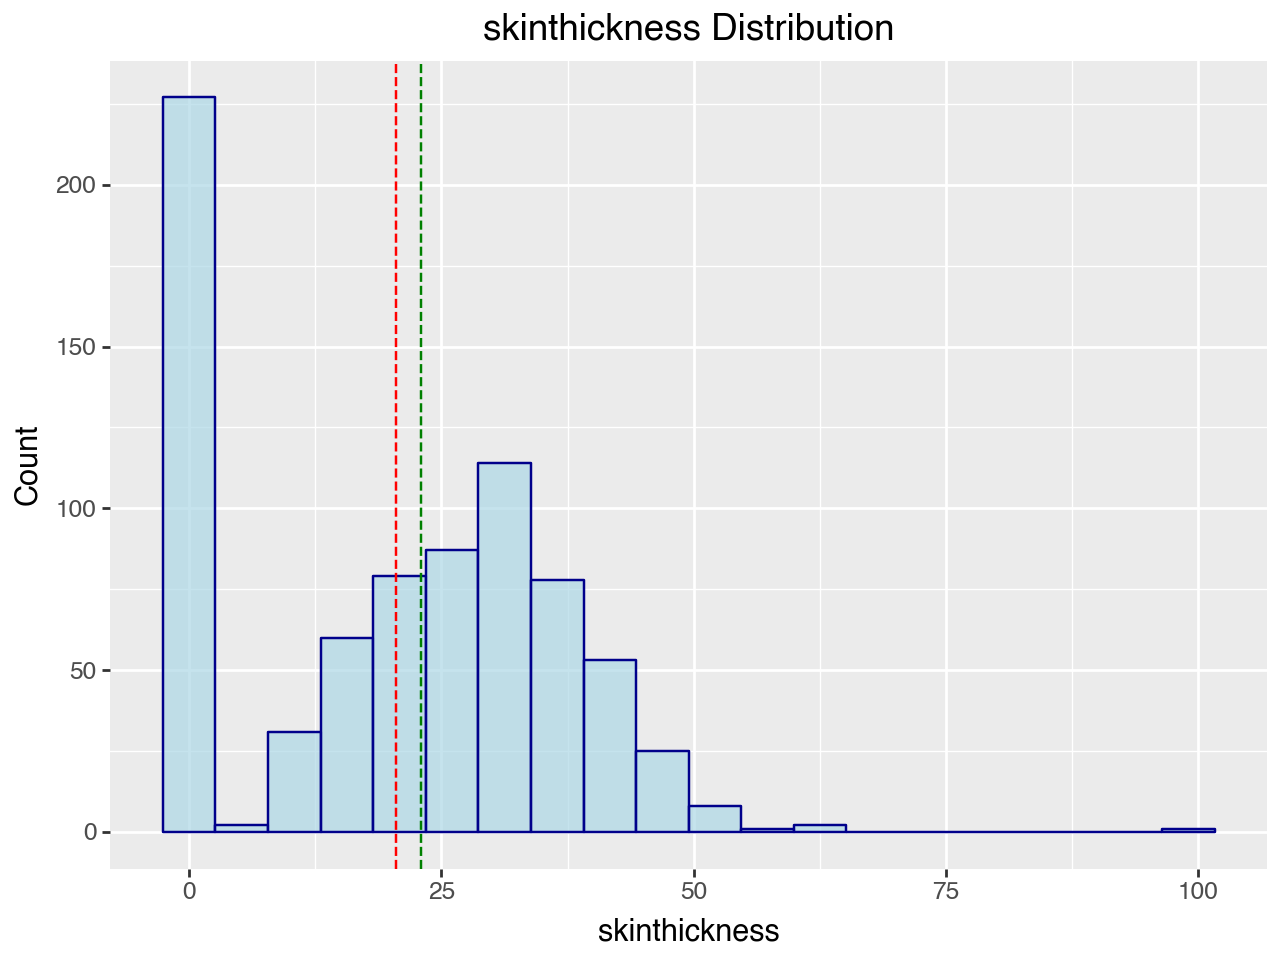

In [109]:
mean = pima_df['skinthickness'].mean()
median = pima_df['skinthickness'].median()

(ggplot(pima_df, aes(x='skinthickness')) + 
        geom_histogram(bins = 20, 
                       fill = 'lightblue', 
                       color = 'darkblue',
                       alpha = 0.7) +
        labs(title = 'skinthickness Distribution', x = 'skinthickness', y = 'Count') + 
        geom_vline(xintercept=mean, color='red', linetype='dashed') +
        geom_vline(xintercept=median, color='green', linetype='dashed'))


**Notes:**
Will impute again.  With some outliers it's probably close to normal. 

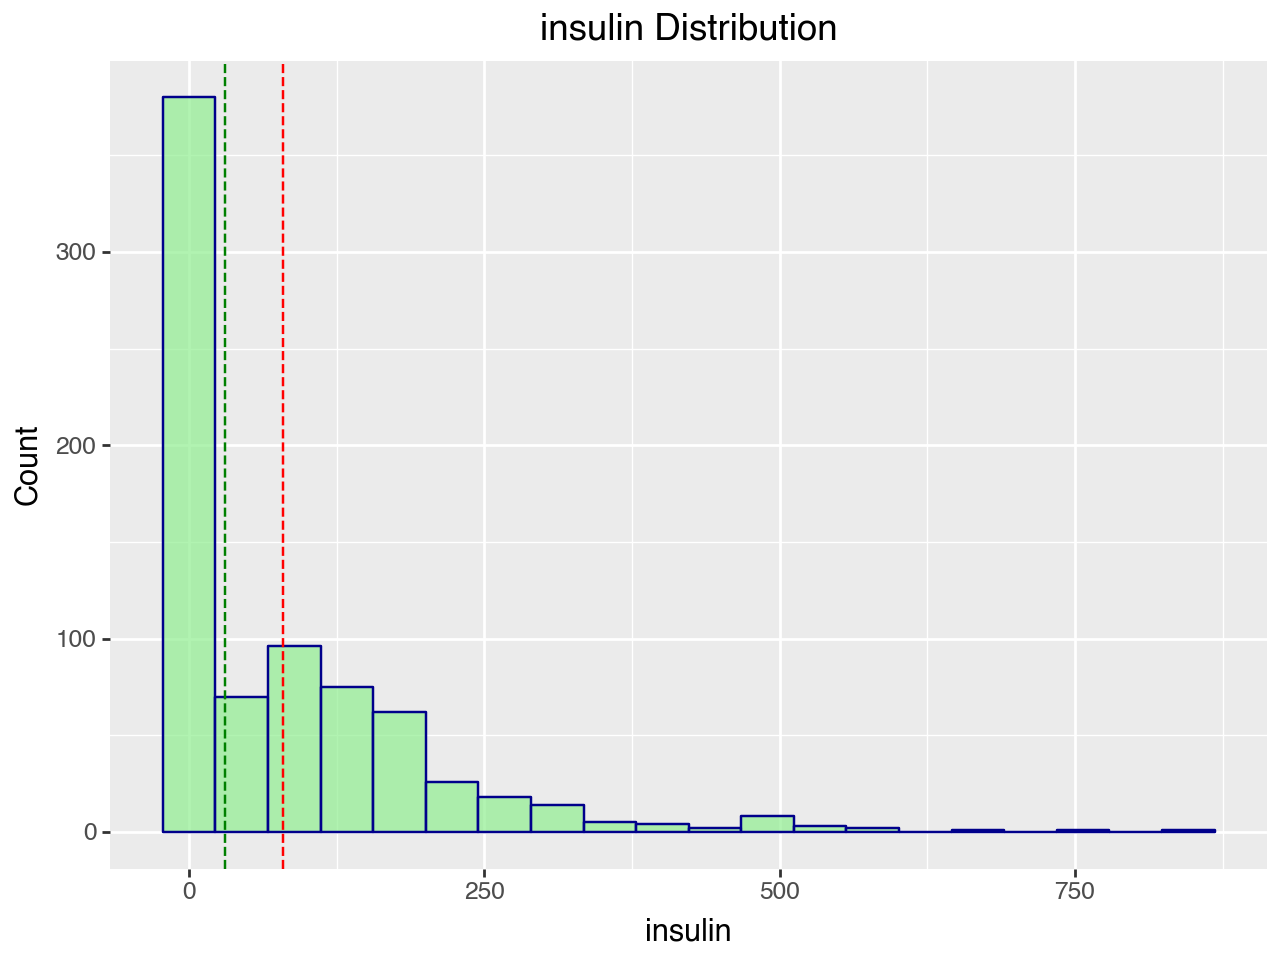

In [110]:
mean = pima_df['insulin'].mean()
median = pima_df['insulin'].median()

(ggplot(pima_df, aes(x='insulin')) + 
        geom_histogram(bins = 20, 
                       fill = 'lightgreen', 
                       color = 'darkblue',
                       alpha = 0.7) +
        labs(title = 'insulin Distribution', x = 'insulin', y = 'Count') + 
        geom_vline(xintercept=mean, color='red', linetype='dashed') +
        geom_vline(xintercept=median, color='green', linetype='dashed'))


**Notes:**
No imputation, patiaent probabgly didn't receive insulin.  let's look at it w/o 0's. 

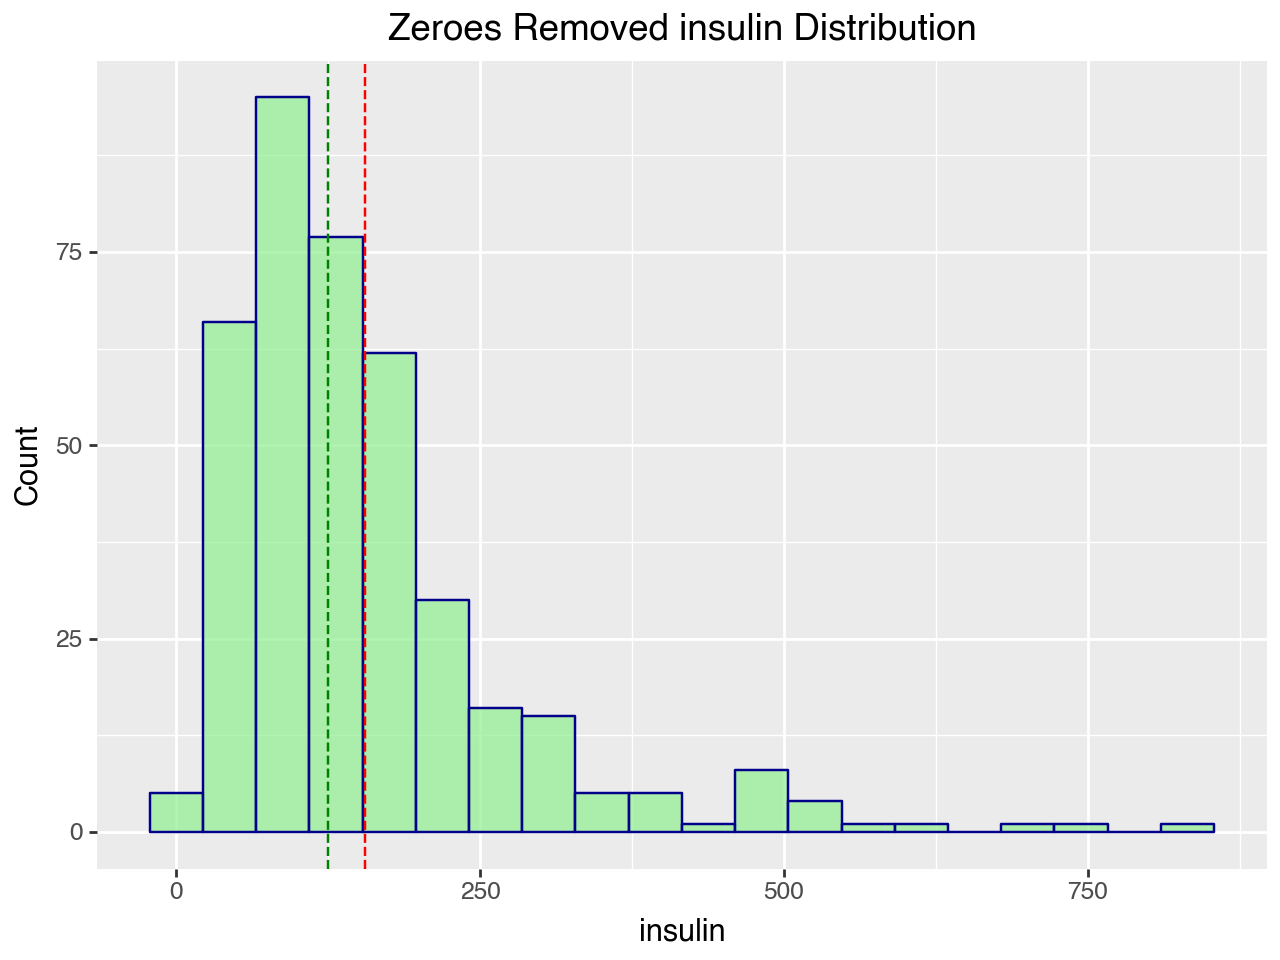

In [111]:
mean = pima_df[pima_df['insulin'] > 0]['insulin'].mean()
median = pima_df[pima_df['insulin'] > 0]['insulin'].median()

(ggplot(pima_df[pima_df['insulin'] > 0], aes(x='insulin')) + 
        geom_histogram(bins = 20, 
                       fill = 'lightgreen', 
                       color = 'darkblue',
                       alpha = 0.7) +
        labs(title = 'Zeroes Removed insulin Distribution', x = 'insulin', y = 'Count') + 
        geom_vline(xintercept=mean, color='red', linetype='dashed') +
        geom_vline(xintercept=median, color='green', linetype='dashed'))

**Notes:**
Skews to the right, with some weird patters near 500, will need to pay attention here. 

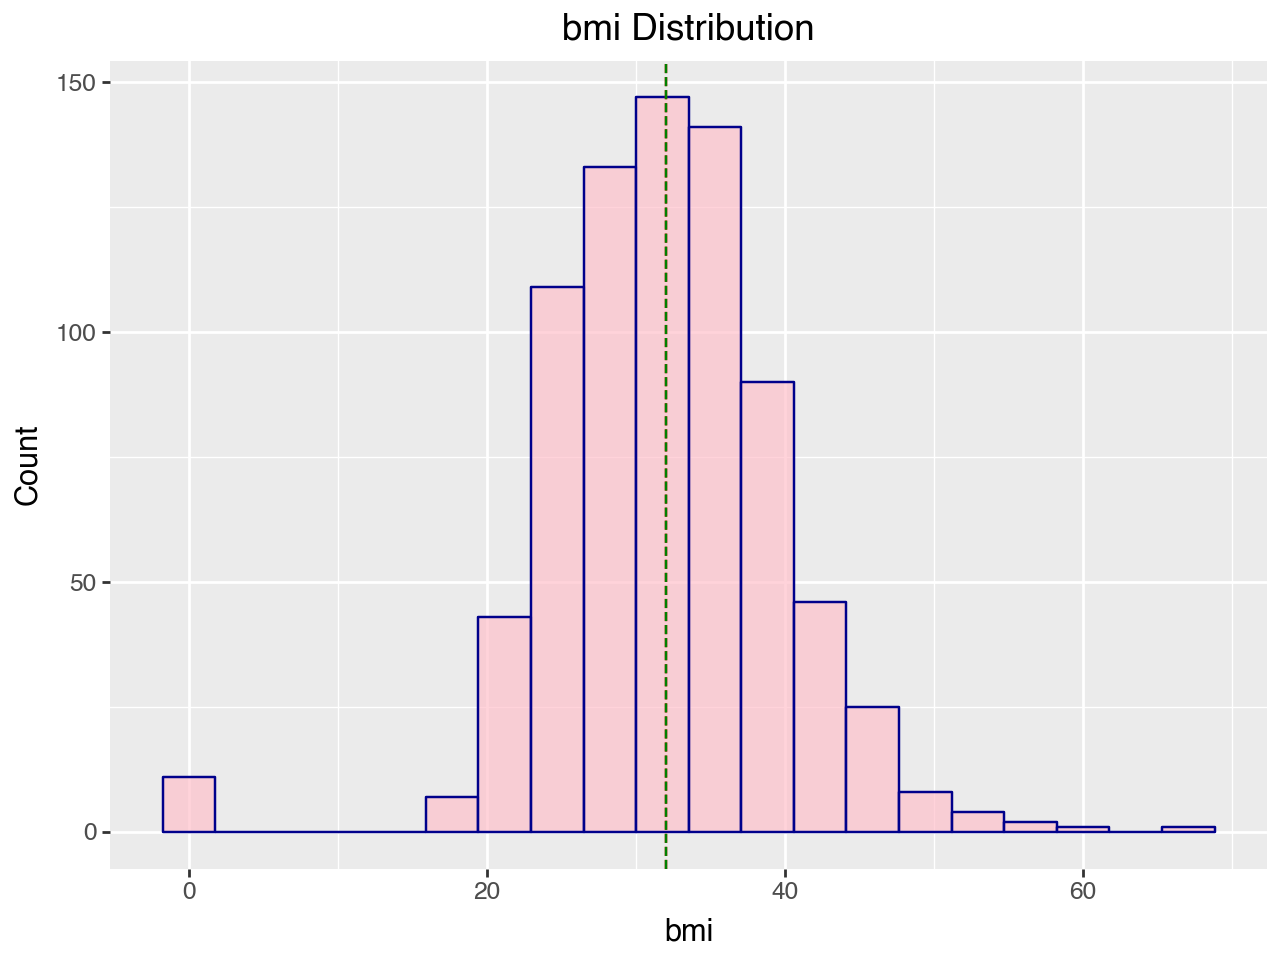

In [112]:
mean = pima_df['bmi'].mean()
median = pima_df['bmi'].median()

(ggplot(pima_df, aes(x='bmi')) + 
        geom_histogram(bins = 20, 
                       fill = 'pink', 
                       color = 'darkblue',
                       alpha = 0.7) +
        labs(title = 'bmi Distribution', x = 'bmi', y = 'Count') + 
        geom_vline(xintercept=mean, color='red', linetype='dashed') +
        geom_vline(xintercept=median, color='green', linetype='dashed'))


**Notes:**
Fairly normal, will impute 0s

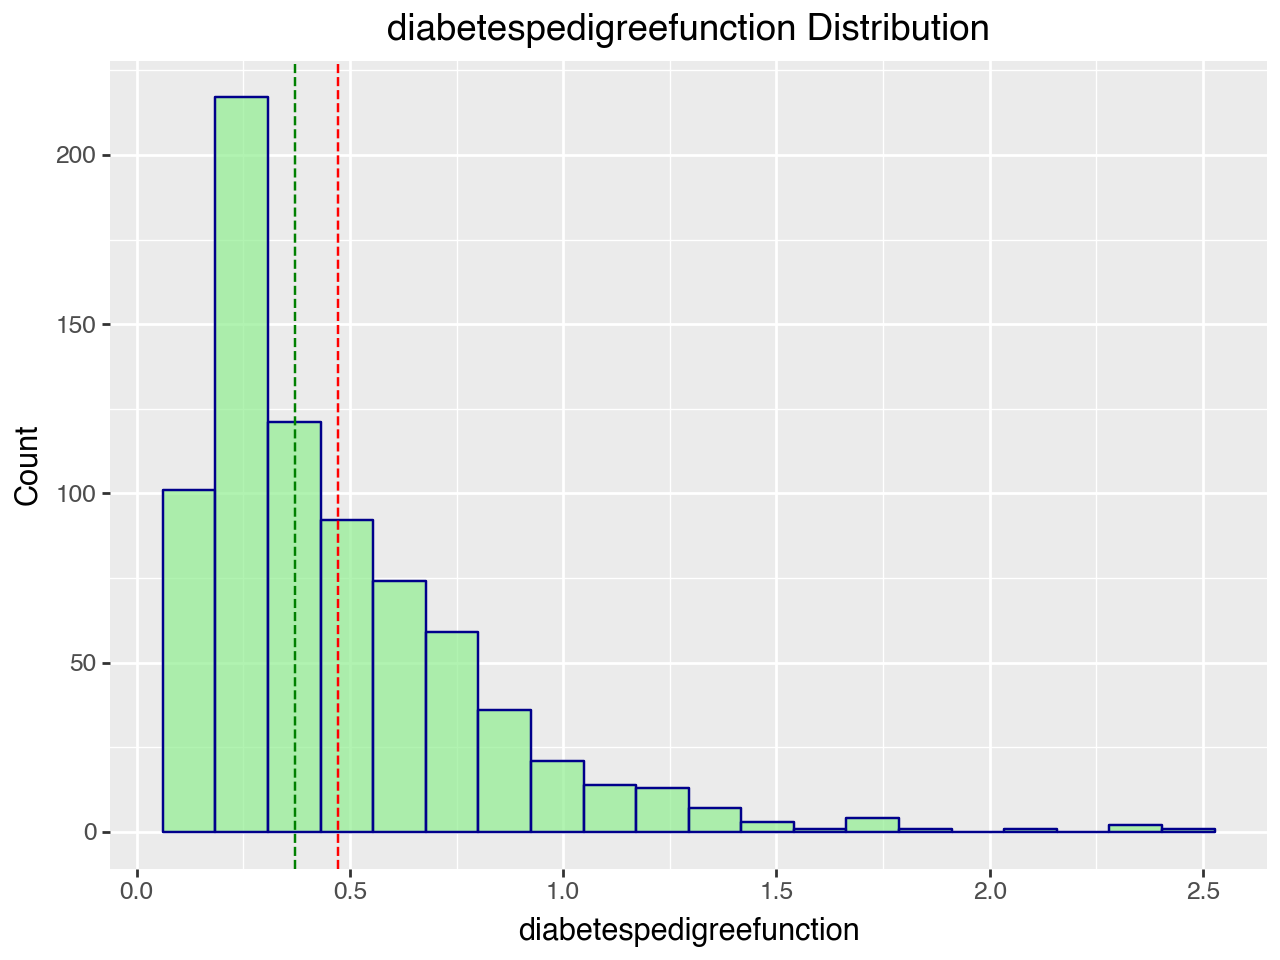

In [116]:
mean = pima_df['diabetespedigreefunction'].mean()
median = pima_df['diabetespedigreefunction'].median()

(ggplot(pima_df, aes(x='diabetespedigreefunction')) + 
        geom_histogram(bins = 20, 
                       fill = 'lightgreen', 
                       color = 'darkblue',
                       alpha = 0.7) +
        labs(title = 'diabetespedigreefunction Distribution', x = 'diabetespedigreefunction', y = 'Count') + 
        geom_vline(xintercept=mean, color='red', linetype='dashed') +
        geom_vline(xintercept=median, color='green', linetype='dashed'))

**Notes:**
Skews to the right

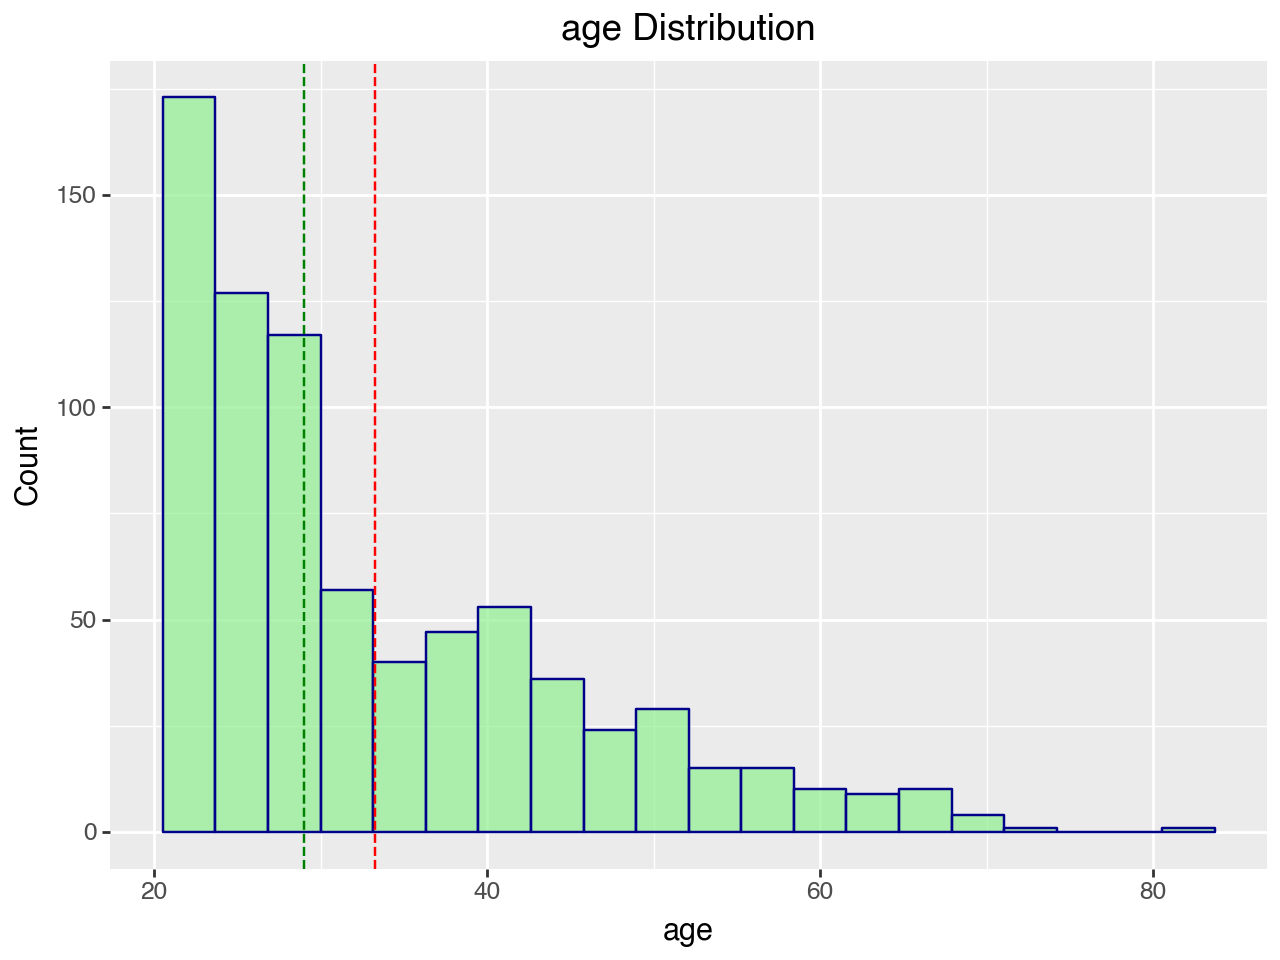

In [117]:
mean = pima_df['age'].mean()
median = pima_df['age'].median()

(ggplot(pima_df, aes(x='age')) + 
        geom_histogram(bins = 20, 
                       fill = 'lightgreen', 
                       color = 'darkblue',
                       alpha = 0.7) +
        labs(title = 'age Distribution', x = 'age', y = 'Count') + 
        geom_vline(xintercept=mean, color='red', linetype='dashed') +
        geom_vline(xintercept=median, color='green', linetype='dashed'))

**Notes:**
Skews to the right,  with ~4 years separation between the mean and the median

##### Fix Imputation found above
We'll use a new dataframe to make comparisons easier and not lose any history

**Note: ** If this was going to be somethign that I need to do over and over I'd start an ML pipeline here for "cleansing" (sklearn Pipeline)

In [118]:
pima_imputed = pima_df.copy()

cols_with_zeros = ['glucose', 'bloodpressure', 'skinthickness', 'bmi']
pima_imputed[cols_with_zeros] = pima_imputed[cols_with_zeros].replace(0, np.nan)

imputer = SimpleImputer(strategy='median')
pima_imputed[cols_with_zeros] = imputer.fit_transform(pima_imputed[cols_with_zeros])

##### Look at the distributions again 

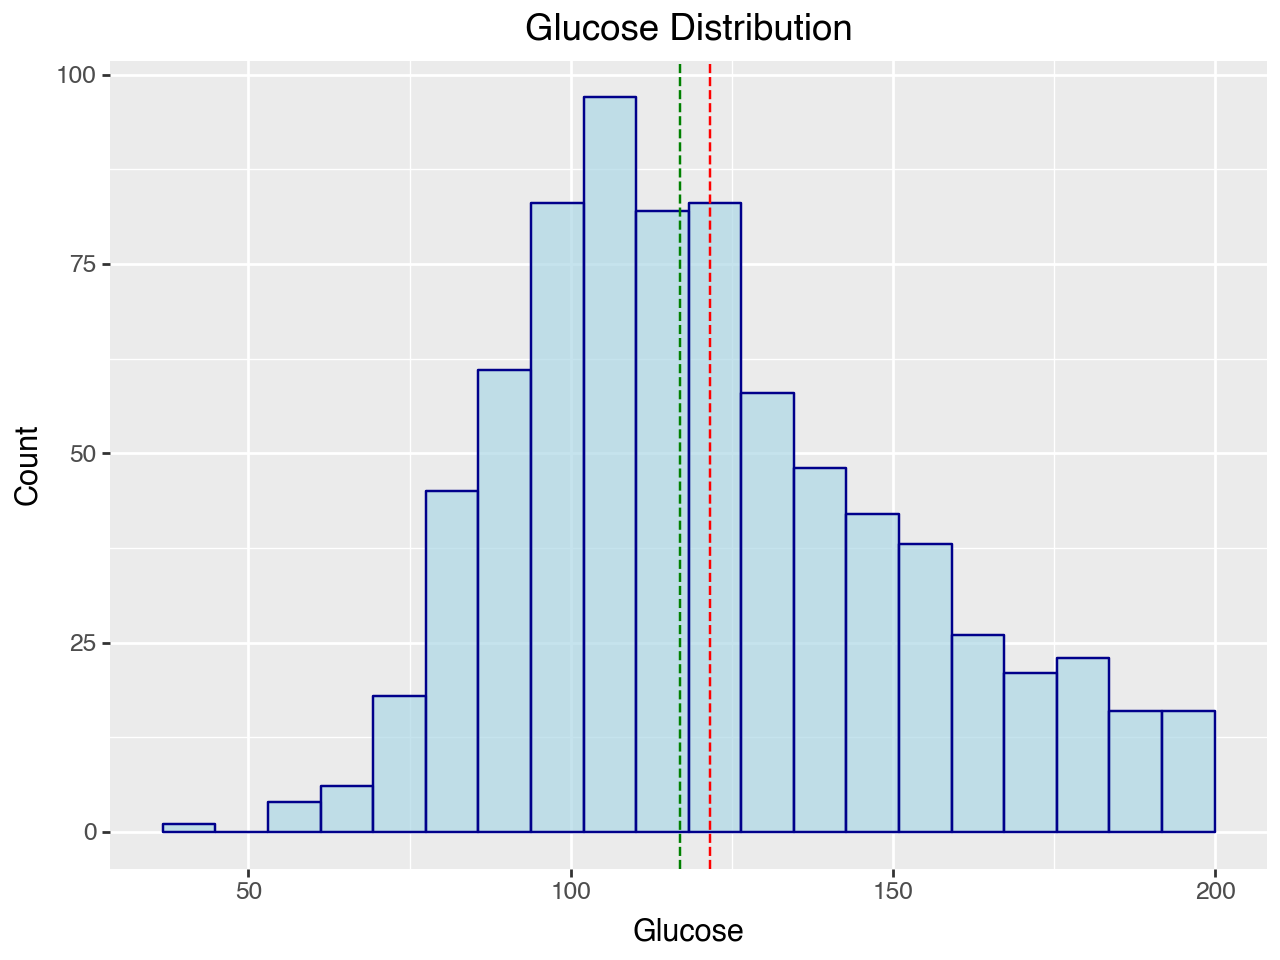

In [119]:
mean = pima_imputed['glucose'].mean()
median = pima_imputed['glucose'].median()

(ggplot(pima_imputed, aes(x='glucose')) + 
        geom_histogram(bins = 20, 
                       fill = 'lightblue', 
                       color = 'darkblue',
                       alpha = 0.7) +
        labs(title = 'Glucose Distribution', x = 'Glucose', y = 'Count') + 
        geom_vline(xintercept=mean, color='red', linetype='dashed') +
        geom_vline(xintercept=median, color='green', linetype='dashed'))

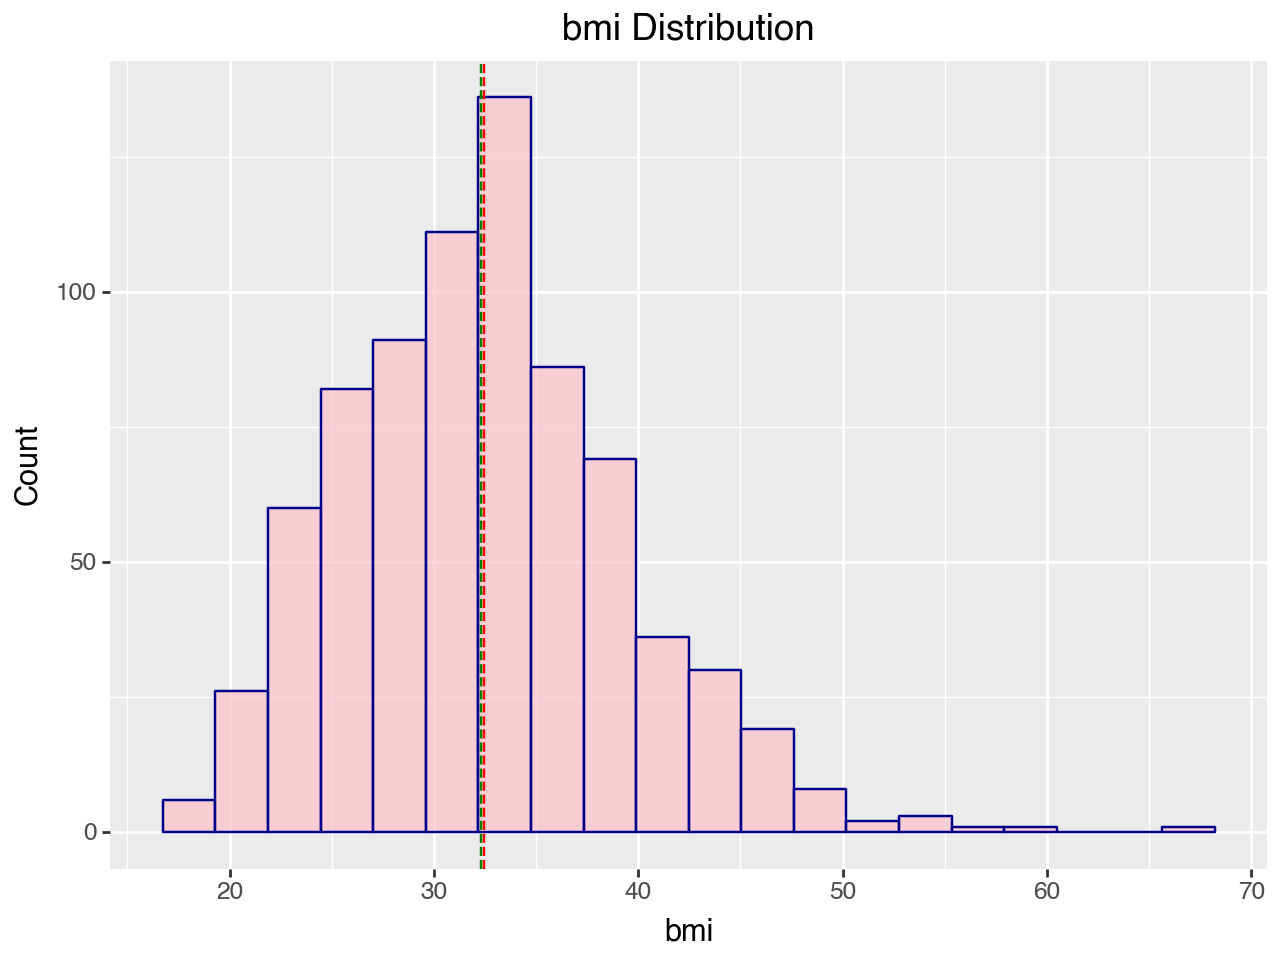

In [120]:
mean = pima_imputed['bmi'].mean()
median = pima_imputed['bmi'].median()

(ggplot(pima_imputed, aes(x='bmi')) + 
        geom_histogram(bins = 20, 
                       fill = 'pink', 
                       color = 'darkblue',
                       alpha = 0.7) +
        labs(title = 'bmi Distribution', x = 'bmi', y = 'Count') + 
        geom_vline(xintercept=mean, color='red', linetype='dashed') +
        geom_vline(xintercept=median, color='green', linetype='dashed'))

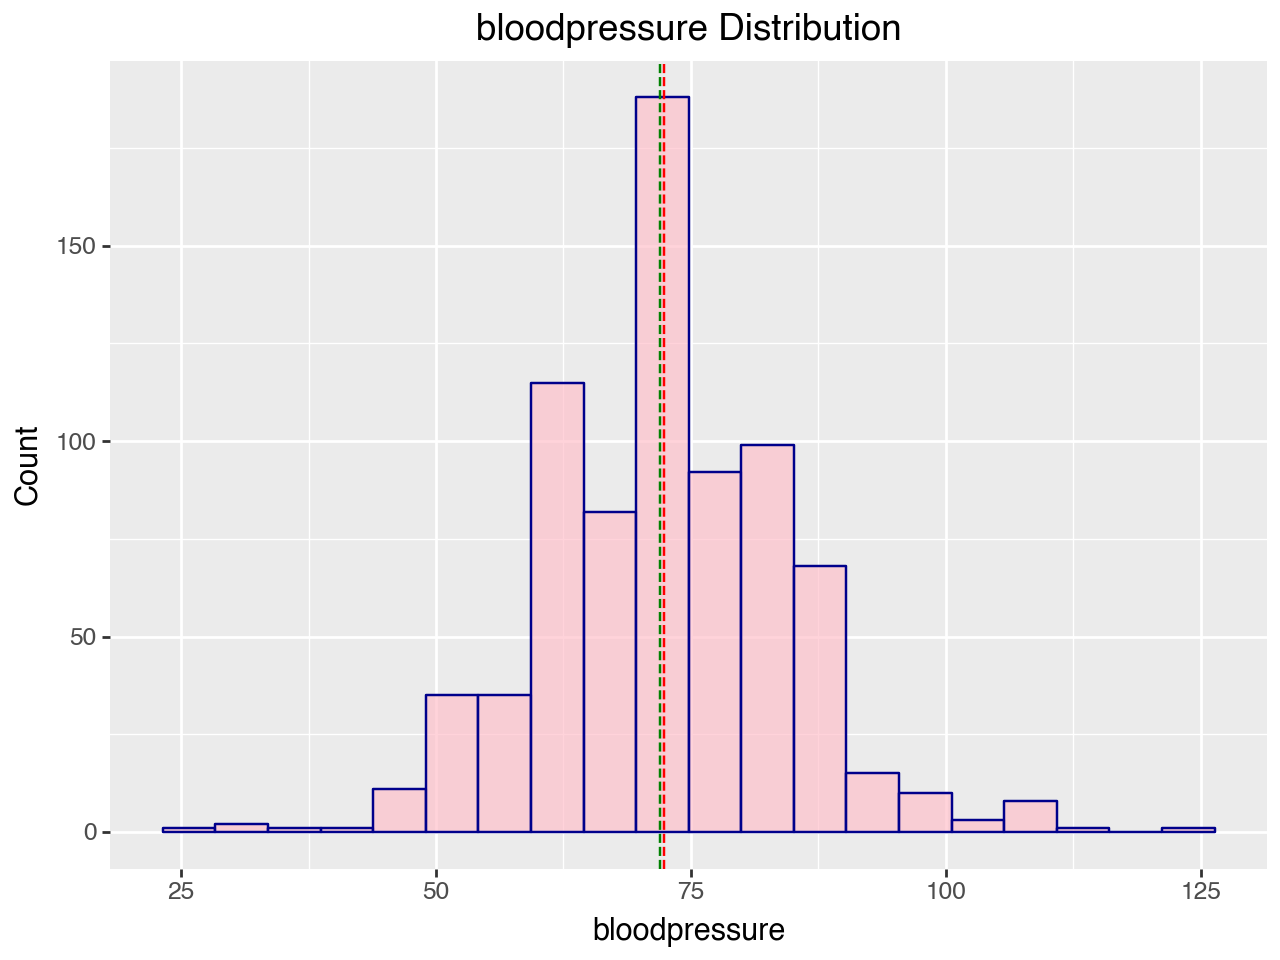

In [121]:
mean = pima_imputed['bloodpressure'].mean()
median = pima_imputed['bloodpressure'].median()

(ggplot(pima_imputed, aes(x='bloodpressure')) + 
        geom_histogram(bins = 20, 
                       fill = 'pink', 
                       color = 'darkblue',
                       alpha = 0.7) +
        labs(title = 'bloodpressure Distribution', x = 'bloodpressure', y = 'Count') + 
        geom_vline(xintercept=mean, color='red', linetype='dashed') +
        geom_vline(xintercept=median, color='green', linetype='dashed'))

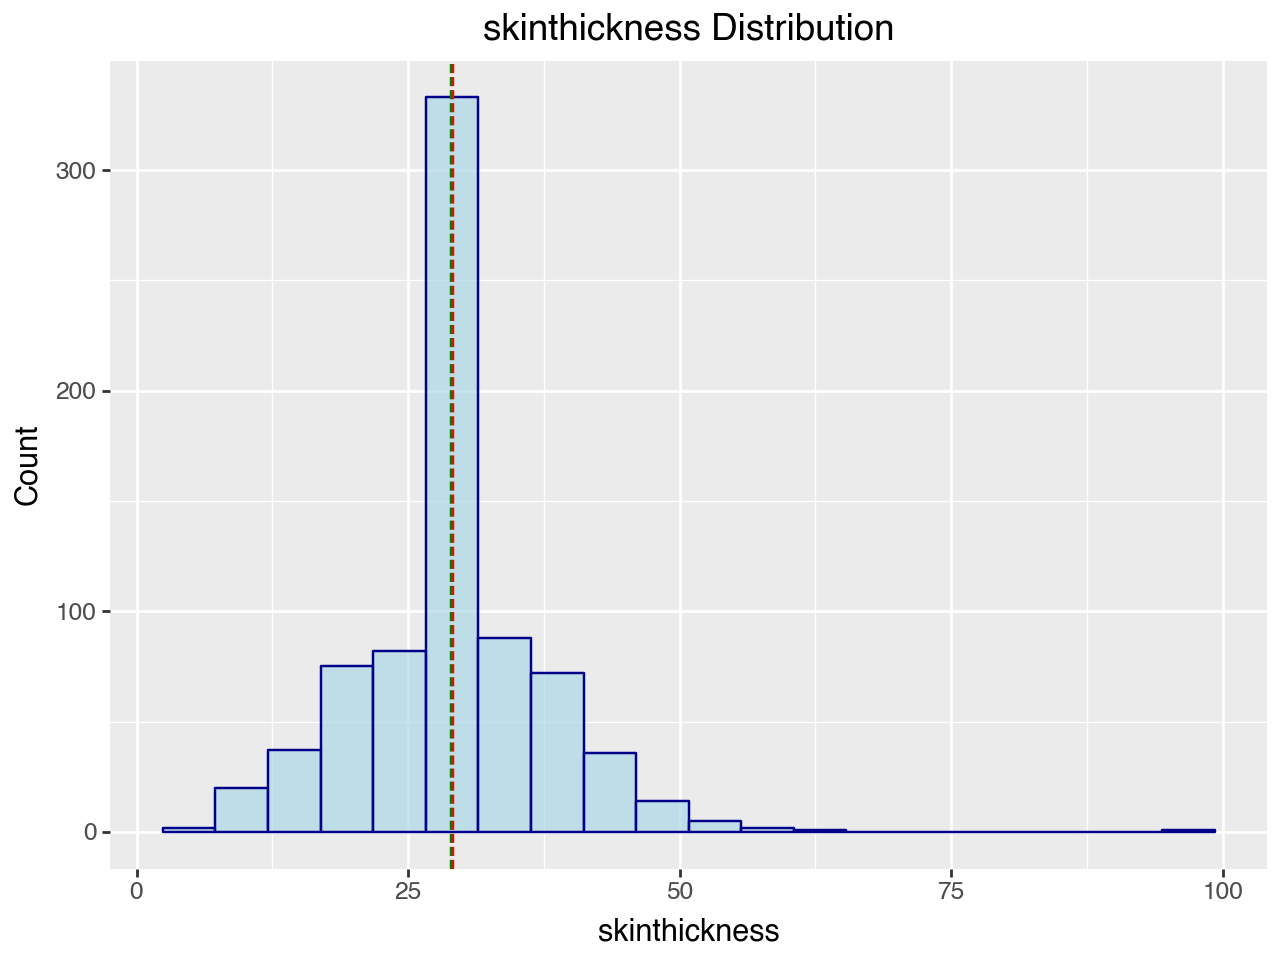

In [122]:
mean = pima_imputed['skinthickness'].mean()
median = pima_imputed['skinthickness'].median()

(ggplot(pima_imputed, aes(x='skinthickness')) + 
        geom_histogram(bins = 20, 
                       fill = 'lightblue', 
                       color = 'darkblue',
                       alpha = 0.7) +
        labs(title = 'skinthickness Distribution', x = 'skinthickness', y = 'Count') + 
        geom_vline(xintercept=mean, color='red', linetype='dashed') +
        geom_vline(xintercept=median, color='green', linetype='dashed'))

**Notes:**

Having been in forecasting for some long imputation is a dangerous thing (I think done appropriately here) but you can see why.  This completely changes the distribution and change the medians and means to collapse together.  Since these are biological markers this makes sense, in other practices this is dirtying the raw data. 

##### Let's look at Correlation First

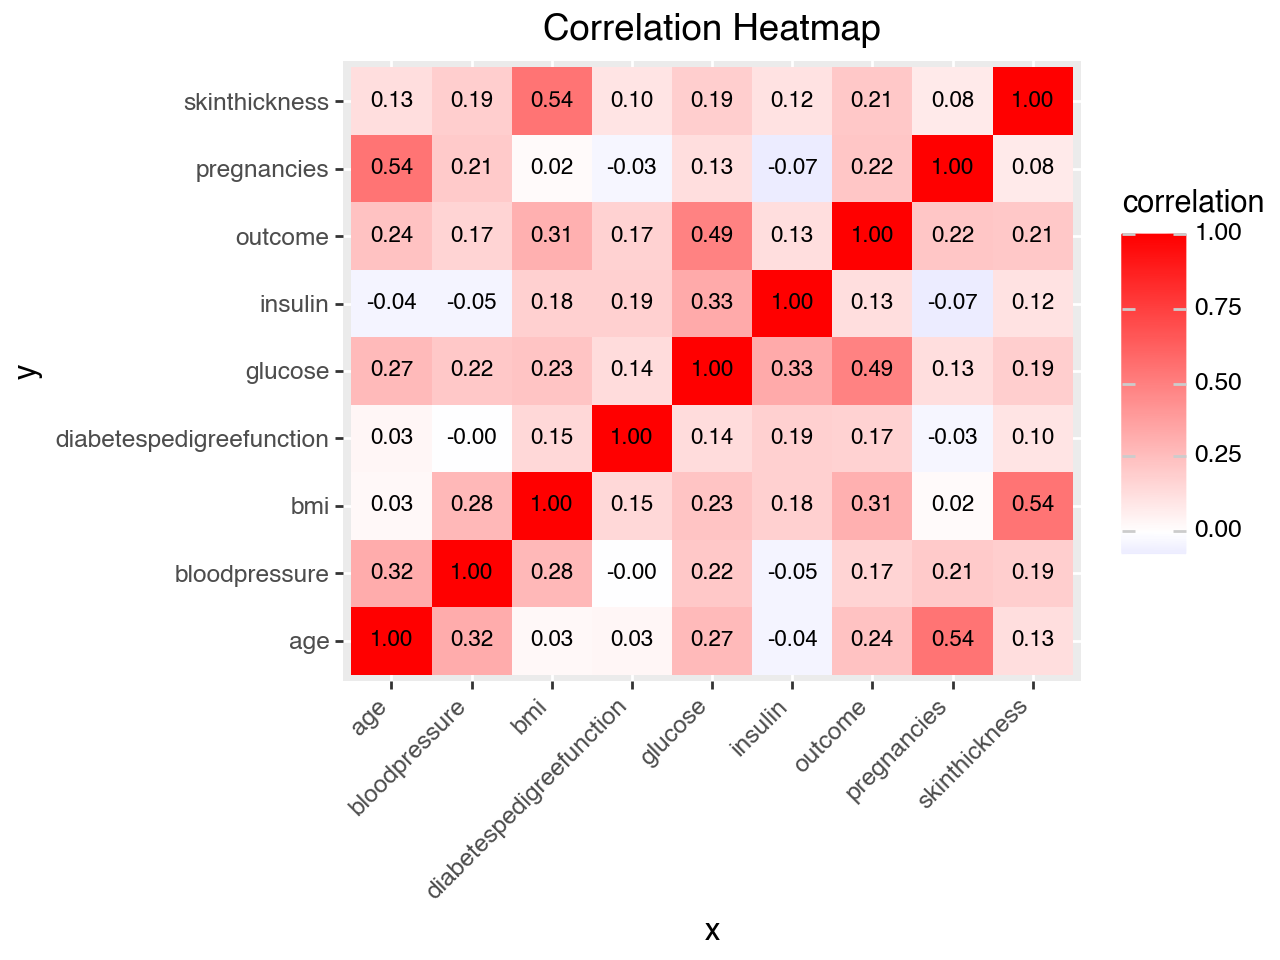

In [124]:
corr = pima_imputed.corr()
corr_long = corr.reset_index().melt(id_vars='index')
corr_long.columns = ['x', 'y', 'correlation']

(ggplot(corr_long, aes(x='x', y='y', fill='correlation'))
 + geom_tile()
 + geom_text(aes(label='correlation'), format_string='{:.2f}', size=8)
 + scale_fill_gradient2(low='blue', mid='white', high='red', midpoint=0)
 + labs(title='Correlation Heatmap')
 + theme(axis_text_x=element_text(angle=45, hjust=1)))

**Notes:**
- age and pregnancies
- insulin and skin thickness
- outcome and glucose :) 
- pregnancies and age
- bmi and skin thickness

These all are close to or greater than 0.5 showing we do have some correlation

##### MultiCollinearity

In [125]:
features = pima_imputed.drop(columns='outcome')
vif = pd.DataFrame({'feature': features.columns,
                    'VIF': [variance_inflation_factor(features.values, i) 
                            for i in range(features.shape[1])]})
print(vif.sort_values('VIF', ascending=False))

                    feature        VIF
5                       bmi  33.811812
2             bloodpressure  32.494434
1                   glucose  20.548084
3             skinthickness  17.292098
7                       age  14.428809
0               pregnancies   3.277668
6  diabetespedigreefunction   3.190417
4                   insulin   1.775624


**Notes:** 

Anyting above 5 is worth thinking about and anything above 10 is worth worrying about.  We could do PCA to try and reduce the correlatred features but it makes more sense to change modeling to xgboost since it doesn't care about this.  This removes regression as an option, but if we have time we can use SHAP to help with explainability. 

#### Test Train Split

In [ ]:
X = pima_imputed.drop(columns='outcome')
y = pima_imputed['outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=seed, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=seed, stratify=y_test)

In [191]:
# calculating scale pos weight as an input for models that can correct for imbalances
scale_pos_weight = (y == 0).sum() / (y == 1).sum()
yes = (y_train == 1).sum()
no = (y_train == 0).sum()
ratio = yes/(yes+no )

print(f"Scale Pos Weight: {scale_pos_weight}")
print(f"Yes: {yes}, No: {no}")
print(f"Ratio: {ratio}")


Scale Pos Weight: 1.8656716417910448
Yes: 201, No: 375
Ratio: 0.3489583333333333


**Notes:** 
It is a bit imbalanced, worth stratifying

#### Modeling

Start with a simple untuned model just to make sure the data looks good and we get an expected outcome.

In [151]:
xgb_model = xgb.XGBClassifier(
    objective = 'binary:logistic',
    eval_metric='logloss',
    scale_pos_weight = scale_pos_weight,
    random_state=seed
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_val)

In [150]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.79      0.81        62
           1       0.65      0.71      0.68        34

    accuracy                           0.76        96
   macro avg       0.74      0.75      0.74        96
weighted avg       0.77      0.76      0.76        96



In [149]:
cm = pd.DataFrame(confusion_matrix(y_val, y_pred),
                  index=['Actual No', 'Actual Yes'],
                  columns=['Pred No', 'Pred Yes'])
cm['Total'] = cm.sum(axis=1)
cm.loc['Total'] = cm.sum()
cm

,Pred No,Pred Yes,Total
Actual No,49,13,62
Actual Yes,10,24,34
Total,59,37,96


##### Modeling to find the right n_estimator
Typically do this first for an xgboost model or anything with n_estimators, just a quick sweep.  

**Note:** This is where I would employ ML Ops to make the search for models easier once run

In [168]:
params = {
    'max_depth': [5],
    'learning_rate': [0.1],
    'n_estimators': [5, 10, 50, 100, 200, 300, 500, 800, 1000],
    'scale_pos_weight': [scale_pos_weight],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

sk = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

xgb_model = XGBClassifier(objective='binary:logistic',
                          random_state=seed)

grid_search = GridSearchCV(estimator=xgb_model,
                          param_grid=params,
                          scoring='f1',
                          cv=sk,
                          verbose=1)

grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 9 candidates, totalling 45 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=1980, shuffle=True),
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_pol...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'colsample_bytree': [0.8], 'learning_rate': [0.1],
                         'max_depth': [5],
                         'n_estimators': [5, 10, 50, 100, 200, 300, 500, 800,
                                          1000],
                         'scale_pos_weight': [1.8656716417910448],
                         'subsample': [0.8]},
             scoring='f1', verbose=1)

This is a replacement for ML Ops, Creating a view to look at the sequence of n_estimators

In [170]:
rows = []
for params in grid_search.cv_results_['params']:
    m = XGBClassifier(**params, objective='binary:logistic', eval_metric='logloss', random_state=42)
    m.fit(X_train, y_train)
    y_pred = m.predict(X_val)
    rows.append({
        'n_estimators': params['n_estimators'],
        'accuracy': accuracy_score(y_val, y_pred),
        'precision': precision_score(y_val, y_pred),
        'recall': recall_score(y_val, y_pred),
        'f1': f1_score(y_val, y_pred),
        'accuracy': accuracy_score(y_val, y_pred)
    })

pd.DataFrame(rows).sort_values('recall', ascending=False)

,n_estimators,accuracy,precision,recall,f1
1,10,0.729167,0.590909,0.764706,0.666667
2,50,0.791667,0.694444,0.735294,0.714286
0,5,0.729167,0.600000,0.705882,0.648649
3,100,0.781250,0.685714,0.705882,0.695652
4,200,0.791667,0.718750,0.676471,0.696970
5,300,0.770833,0.687500,0.647059,0.666667
6,500,0.760417,0.677419,0.617647,0.646154
7,800,0.760417,0.677419,0.617647,0.646154
8,1000,0.760417,0.677419,0.617647,0.646154


**Notes:**
the sweet spot is somewehre between 20 and 250 probably

In [178]:
params = {
    'max_depth': [3, 5, 6, 8],
    'n_estimators': [25, 50, 100, 200, 250],
    'scale_pos_weight': [scale_pos_weight],
    'learning_rate': np.logspace(-3, 0, 150),
    'subsample': np.linspace(0.6, 1.0, 5),
    'colsample_bytree': np.linspace(0.6, 1.0, 5),
    'min_child_weight': np.linspace(1, 10, 5, dtype=int),
    'gamma': np.logspace(-3, 0, 5)
}

sk = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

xgb_model = XGBClassifier(objective='binary:logistic',
                          random_state=seed)

grid_search_wide = RandomizedSearchCV(estimator=xgb_model,
                          param_distributions=params,
                          scoring='f1',
                          cv=sk,
                          verbose=1,
                          n_iter=50) # this based on time

grid_search_wide.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=1980, shuffle=True),
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           gr...
       0.52254152, 0.54733728, 0.57330966, 0.60051449, 0.62901024,
       0.65885819, 0.69012248, 0.72287034, 0.75717215, 0.79310166,
       0.83073611, 0.87015639, 0.91144726, 0.95469747, 1.        ]),
                                        'max_depth': [3, 5, 6, 8],
                                        'min_child_weight': array([ 1,  3,  5,  7, 10]),
                                        'n_estimators': [25, 50, 100, 200, 250],
                                        'scale_pos_weight': [1.8656716417910448],
                                        'subsample': array([0.6, 0.7, 0.8, 0.9, 1. ])},
                   scoring='f1', verbose=1)

In [179]:
print(grid_search_wide.best_params_)
print(grid_search_wide.best_score_)

{'subsample': 1.0, 'scale_pos_weight': 1.8656716417910448, 'n_estimators': 250, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.010155736154404175, 'gamma': 0.1778279410038923, 'colsample_bytree': 0.9}
0.7021364211543719


In [196]:
y_pred = grid_search_wide.predict(X_test)
y_prob = grid_search_wide.best_estimator_.predict_proba(X_test)[:, 1]

In [197]:
cm = pd.DataFrame(confusion_matrix(y_test, y_pred),
                  index=['Actual No', 'Actual Yes'],
                  columns=['Pred No', 'Pred Yes'])
cm['Total'] = cm.sum(axis=1)
cm.loc['Total'] = cm.sum()
cm

,Pred No,Pred Yes,Total
Actual No,47,16,63
Actual Yes,8,25,33
Total,55,41,96


In [198]:
metrics = pd.DataFrame({'Metric': ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC'],
                        'Score': [accuracy_score(y_test, y_pred),
                                  precision_score(y_test, y_pred),
                                  recall_score(y_test, y_pred),
                                  f1_score(y_test, y_pred),
                                  roc_auc_score(y_test, y_prob)]})

metrics

,Metric,Score
0,Accuracy,0.750000
1,Precision,0.609756
2,Recall,0.757576
3,F1,0.675676
4,ROC-AUC,0.802309


In [199]:
# feature importance
imp = pd.Series(grid_search_wide.best_estimator_.feature_importances_, index=X_train.columns)
print(imp.sort_values(ascending=False))

glucose                     0.341103
age                         0.159992
bmi                         0.153410
diabetespedigreefunction    0.080017
pregnancies                 0.078308
skinthickness               0.078015
bloodpressure               0.055154
insulin                     0.054001
dtype: float32


#### Summary / What did we learn

We have a decently tuned XGBoost model that has decent accuracy recall and precision.  An F1 score of 0.7 gives us a good balance between precision and recall and the ROC-AUC of 0.80 means we're choosing correctly on true-positives most 80% of the time and overfitting is likely not a concern. 

Glucose is the strongest predictor, which our correlation heatmap indicated it probably would be. 